# Фильтр Калмана

In [1]:
!pip install pykalman

In [2]:
# Подгружаем необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\Zorin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Zorin\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [3]:
# Загружаем данные
df = pd.read_csv('Диплом данные - Лист1.csv') #данные с декабря 2019 года по декабрь 2024 года
df.head()

,Unnamed: 0,Ожидаемая наседением инфляция,"ИПЦ, г/г","ИПЦ, м/м","ИПЦ продовольствие, м/м","ИПЦ продовольствие, г/г","ИПЦ непродовольствие, м/м","ИПЦ непродовольствие, г/г","Денежный агрегат М2,млрд. руб.","Прямой валютный курс, USD/RUB"
0,12.2009,NaN,"8,80",NaN,NaN,"6,08",NaN,"9,65",NaN,NaN
1,1.2010,NaN,"8,02","101,64","101,42","6,10","100,23","9,12",15268.0,"30,37"
2,2.2010,NaN,"7,18","100,86","101,26","5,49","100,30","7,72",14904.0,"29,94"
3,3.2010,NaN,"6,46","100,63","101,03","4,80","100,39","6,62",15236.0,"29,43"
4,4.2010,"14,40","6,04","100,29","100,30","4,39","100,34","5,93",15639.0,"29,23"


In [4]:
df_inf = pd.read_csv('наблюдаемая инфляция - Лист1.csv')
df = pd.concat([df, df_inf[['наблюдаемая населением инфляция ']]], axis=1)

In [5]:
# Приводим данные к нужному формату
df.drop(columns = 'Unnamed: 0', inplace = True)

for column in df.columns[:7]:
  df[column] = df[column].str.replace(',', '.').astype(float)

df['Прямой валютный курс, USD/RUB'] = df['Прямой валютный курс, USD/RUB'].str.replace(',', '.').astype(float)

# Преобразуем в pandas Series
obs_exp = df['Ожидаемая наседением инфляция']

# Применяем скользящее среднее с окном, например, 7
obs_exp = obs_exp.fillna(obs_exp.rolling(window=7, min_periods=1).mean())

obs_exp = obs_exp.fillna(obs_exp.mean())

df[["ИПЦ, м/м ", "ИПЦ продовольствие, м/м", "ИПЦ непродовольствие, м/м"]] = df[["ИПЦ, м/м ", "ИПЦ продовольствие, м/м", "ИПЦ непродовольствие, м/м"]] - 100

In [6]:
# Создадим таблицу-шаблон, куда будем ложить все получившиеся ряды для истинных
#инфляционных ожиданий
df_clean_exp = pd.DataFrame(np.nan, index=range(180), columns = [
      "ИПЦ, г/г",
      "ИПЦ продовольствие, г/г",
      "ИПЦ непродовольствие, г/г"
  ])

# Прогноз на 12 месяцев

Анализ: ИПЦ,  г/г

Оценённые параметры:
  Transition matrix (A): 0.9782
  Transition offset (alpha): 0.1594
  Transition covariance (Q): 0.1708
  Observation covariance (R): 3.6555

Корреляции:
  Прогноз t+12 vs ожидания населения: r = 0.5139, p = 0.0000
  Прогноз t+12 vs фактическая инфляция: r = 0.8701, p = 0.0000


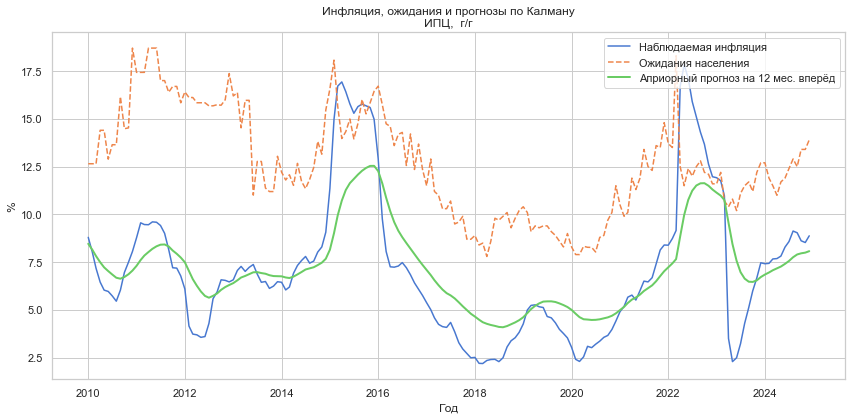

Анализ: ИПЦ продовольствие, г/г

Оценённые параметры:
  Transition matrix (A): 0.9790
  Transition offset (alpha): 0.1673
  Transition covariance (Q): 0.1308
  Observation covariance (R): 13.3159

Корреляции:
  Прогноз t+12 vs ожидания населения: r = 0.5270, p = 0.0000
  Прогноз t+12 vs фактическая инфляция: r = 0.6842, p = 0.0000


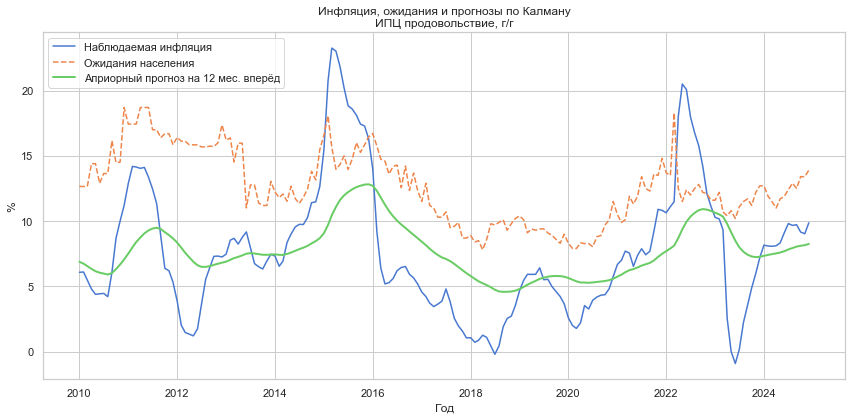

Анализ: ИПЦ непродовольствие, г/г

Оценённые параметры:
  Transition matrix (A): 0.9737
  Transition offset (alpha): 0.1710
  Transition covariance (Q): 0.1284
  Observation covariance (R): 6.2476

Корреляции:
  Прогноз t+12 vs ожидания населения: r = 0.3383, p = 0.0000
  Прогноз t+12 vs фактическая инфляция: r = 0.7641, p = 0.0000


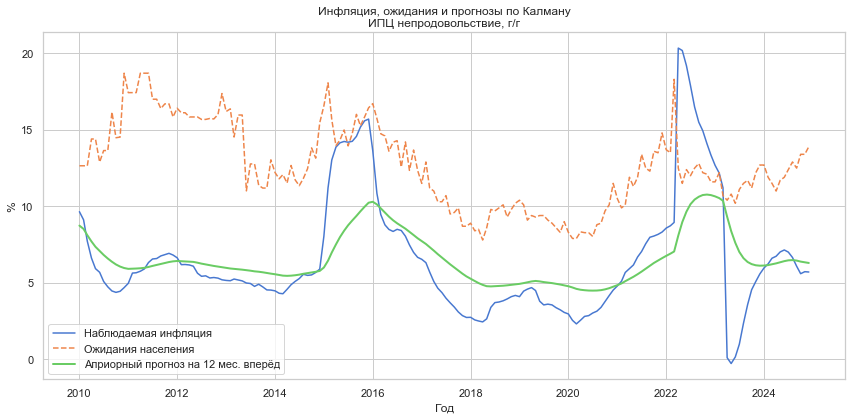

In [7]:
dates = np.arange('2010-01', '2025-01', dtype='datetime64[M]')
expectations = obs_exp.values[1:]  # ожидания населения с января 2010

# Список колонок для анализа
columns = [
    'ИПЦ,  г/г',
    'ИПЦ продовольствие, г/г',
    'ИПЦ непродовольствие, г/г'
]

# Словари для хранения результатов
forecast_results = {}
params_results = {}
filtered_results = {}

# Функция для прогноза на 12 месяцев вперед

def forecast_12_ahead(state_mean, state_cov, phi, alpha, q):
    "Прогноз на 12 месяцев вперед из априорного состояния"
    mean = phi**12 * state_mean + alpha * (1 - phi**12) / (1 - phi)
    var = phi**24 * state_cov + q * (1 - phi**24) / (1 - phi**2)
    return mean.item(), var.item()

for col in columns:
    print(f"Анализ: {col}")
    
    # Подготовка данных
    observations = df[col].to_numpy()[:-1]
    
    # Параметры модели AR(1)
    phi = 0.95
    alpha = 0.2
    transition_matrix = np.array([[phi]])
    transition_offset = np.array([alpha])
    observation_matrix = np.array([[1]])
    transition_covariance = np.array([[0.02]])
    observation_covariance = np.array([[3]])
    initial_state_mean = 10
    initial_state_covariance = np.array([[100]])
    
    # Kalman Filter
    kf = KalmanFilter(
        transition_matrices=transition_matrix,
        transition_offsets=transition_offset,
        observation_matrices=observation_matrix,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
        initial_state_mean=initial_state_mean,
        initial_state_covariance=initial_state_covariance,
    )
    
    # Оценка параметров через EM-алгоритм
    kf = kf.em(observations, n_iter=7, em_vars=[
        'transition_matrices',
        'transition_offsets',
        'transition_covariance',
        'observation_covariance'
    ])
    
    # Обновлённые параметры
    phi_est = kf.transition_matrices[0, 0]
    alpha_est = kf.transition_offsets[0]
    q_est = kf.transition_covariance[0, 0]
    r_est = kf.observation_covariance[0, 0]
    
    print(f"\nОценённые параметры:")
    print(f"  Transition matrix (A): {phi_est:.4f}")
    print(f"  Transition offset (alpha): {alpha_est:.4f}")
    print(f"  Transition covariance (Q): {q_est:.4f}")
    print(f"  Observation covariance (R): {r_est:.4f}")
    
    # Сохраняем параметры
    params_results[col] = {
        'phi': phi_est,
        'alpha': alpha_est,
        'q': q_est,
        'r': r_est
    }
    
    # Фильтр Калмана
    filtered_means, filtered_covs = kf.filter(observations)
    
    # Прогноз на 12 месяцев вперёд из априорного состояния
    forecast_12_means = []
    forecast_12_vars = []
    
    for i in range(len(observations)):
        prior_mean = phi_est * filtered_means[i] + alpha_est
        prior_cov = phi_est**2 * filtered_covs[i] + q_est
        m, v = forecast_12_ahead(prior_mean, prior_cov, phi_est, alpha_est, q_est)
        forecast_12_means.append(m)
        forecast_12_vars.append(v)
    
    forecast_12_means = np.array(forecast_12_means)
    forecast_results[col] = forecast_12_means
    
    # Корреляции
    corr_with_exp, p_val_exp = pearsonr(forecast_12_means, expectations)
    corr_with_obs, p_val_obs = pearsonr(forecast_12_means, observations)
    
    print(f"\nКорреляции:")
    print(f"  Прогноз t+12 vs ожидания населения: r = {corr_with_exp:.4f}, p = {p_val_exp:.4f}")
    print(f"  Прогноз t+12 vs фактическая инфляция: r = {corr_with_obs:.4f}, p = {p_val_obs:.4f}")
    
    # Сохраняем корреляции
    params_results[col]['corr_with_exp'] = corr_with_exp
    params_results[col]['corr_with_obs'] = corr_with_obs
    
    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.plot(dates, observations, label='Наблюдаемая инфляция', linewidth=1.5)
    plt.plot(dates, expectations, label='Ожидания населения', linestyle='--')
    plt.plot(dates, forecast_12_means, label='Априорный прогноз на 12 мес. вперёд', linewidth=2)
    plt.title(f'Инфляция, ожидания и прогнозы по Калману\n{col}')
    plt.xlabel('Год')
    plt.ylabel('%')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
# Получаем прогнозы для каждой колонки
forecast_cpi = forecast_results['ИПЦ,  г/г']
forecast_cpi_prod = forecast_results['ИПЦ продовольствие, г/г']
forecast_cpi_neprod = forecast_results['ИПЦ непродовольствие, г/г']

# Создаем DataFrame с прогнозами
df_results = pd.DataFrame({
    'ИПЦ, г/г': forecast_cpi,
    'ИПЦ продовольствие, г/г': forecast_cpi_prod,
    'ИПЦ непродовольствие, г/г': forecast_cpi_neprod
}, index=dates)

# Сохраняем в csv
df_results.to_csv('inflation_expectations_hope.csv', index_label='Дата', encoding='utf-8')

In [9]:
print("Сводная таблица параметров")
params_df = pd.DataFrame(params_results).T
print(params_df)

Сводная таблица параметров
                                phi     alpha         q          r  \
ИПЦ,  г/г                  0.978242  0.159402  0.170763   3.655522   
ИПЦ продовольствие, г/г    0.978957  0.167253  0.130824  13.315894   
ИПЦ непродовольствие, г/г  0.973671  0.171029  0.128440   6.247642   

                           corr_with_exp  corr_with_obs  
ИПЦ,  г/г                       0.513942       0.870079  
ИПЦ продовольствие, г/г         0.527029       0.684194  
ИПЦ непродовольствие, г/г       0.338331       0.764107  


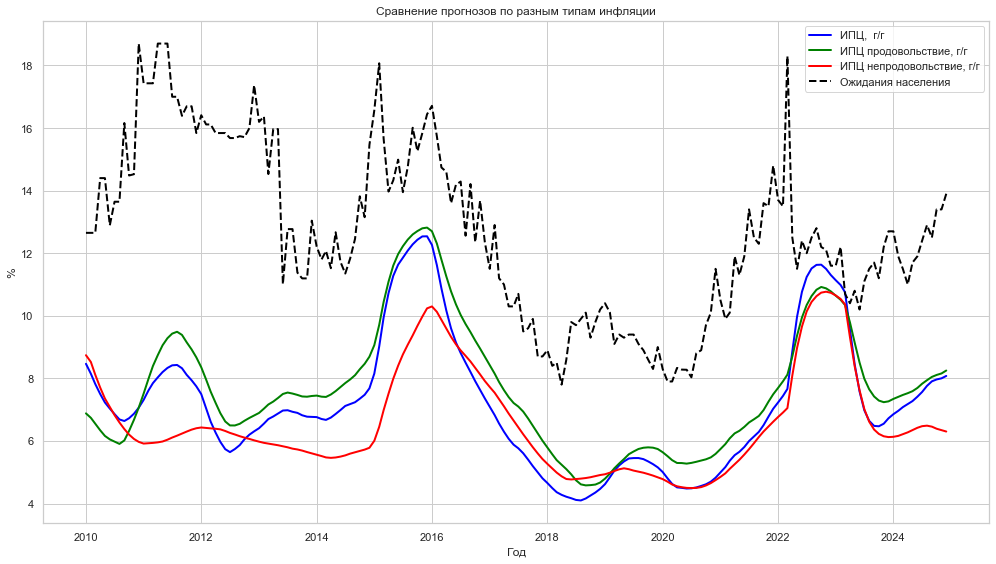

In [10]:
plt.figure(figsize=(14, 8))
colors = ['blue', 'green', 'red']
for i, col in enumerate(columns):
    plt.plot(dates, forecast_results[col], label=col, color=colors[i], linewidth=2)

plt.plot(dates, expectations, label='Ожидания населения', linestyle='--', color ='black', linewidth=2)
plt.title('Сравнение прогнозов по разным типам инфляции')
plt.xlabel('Год')
plt.ylabel('%')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()